# Optimized Production Notebook: Temporal Pseudo-Labeling & Shared Drive Upload

This document represents the fully optimized, production-ready Jupyter Notebook structure to run the **Fase 0: Pseudo-Labeling Temporal** stage in Google Colab.

In this stage, **only the JSON coordinate file (`static_vehicles.json`) is generated**. No images are altered yet. All critical fixes (radians-to-degrees conversion, filename-based frame index parsing to prevent desync, and dynamic class mapping) are fully integrated.

---

## 1. Execution & Time Estimates

* **Inference Model**: `yolo26m-obb.pt` (Medium OBB model, 21.2M parameters) loaded on a Google Colab **T4 GPU**.
* **Processing Speed**: Processing a single video clip of 50 frames (predicting OBB shapes + estimating ORB+RANSAC homography + tracking centroids) takes approximately **20 to 24 seconds**.
* **Total Time**:
  * Running the pipeline on the filtered training split (870 clips) takes:
    $$870 \text{ clips} \times 22 \text{ seconds/clip} \approx 19,140 \text{ seconds} \approx 5.3 \text{ hours}$$
  * This fits easily within Colab's standard 12-hour session limits. With our **skip/checkpointing mechanism**, the run can be stopped and resumed at any time, or parallelized across multiple accounts.

---

## Cell 1: Environment Setup and Library Installation
Install the necessary packages (including the Google API client for shared drive uploads) and import standard modules.



In [1]:
# Install Ultralytics and Google API Client libraries
!pip install -q ultralytics google-api-python-client google-auth-httplib2 google-auth-oauthlib

import os
import cv2
import json
import math
import zipfile
import io
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from google.colab import drive
from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseUpload

# Mount Google Drive (for config/token files)
drive.mount('/content/drive')

# Paths inside Google Colab environment
DRIVE_DIR = "/content/drive/MyDrive/ia_article"
CSV_PATH = os.path.join(DRIVE_DIR, "00_raw/train.csv")
IMAGES_ZIP_PATH = os.path.join(DRIVE_DIR, "00_raw/train.zip")
METADATA_PATH = os.path.join(DRIVE_DIR, "01_processed/split_metadata.csv")

# Google Drive API configuration for shared storage upload
TOKEN_PATH = os.path.join(DRIVE_DIR, "token/token.json")
CARPETA_DESTINO_ID = '1J5ogC3q6jyYlk3wuYyxpYZHslUg6eGtN' # Target shared drive folder (02_pseudo_labeling)

print("Libraries imported. Paths configured.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.9 MB/s eta 0:00:00
Mounted at /content/drive
Libraries imported. Paths configured.


## Cell 2: Google Drive Shared Upload Utility
Since your personal Google Drive accounts might have a 15GB storage limit, this cell defines an API helper function that uploads files **directly to your shared team folder** using a service token, completely bypassing your local Drive storage limits.



In [2]:
def subir_archivo_a_drive_compartido(local_file_path, mime_type='application/json'):
    """
    Uploads a local file directly to the shared team folder on Google Drive
    using authorized credentials, avoiding filling up limited local storage.
    """
    if not os.path.exists(TOKEN_PATH):
        raise FileNotFoundError(f"No se encuentra el token de autenticación en: {TOKEN_PATH}")

    # Load credentials using authorized user token
    creds = Credentials.from_authorized_user_file(TOKEN_PATH, ['https://www.googleapis.com/auth/drive.file'])
    service = build('drive', 'v3', credentials=creds)

    filename = os.path.basename(local_file_path)

    with open(local_file_path, 'rb') as f:
        file_data = f.read()

    flujo_archivo = io.BytesIO(file_data)

    # Metadata detailing name, mime type, and parent folder ID
    metadatos = {
        'name': filename,
        'mimeType': mime_type,
        'parents': [CARPETA_DESTINO_ID]
    }

    media = MediaIoBaseUpload(flujo_archivo, mimetype=mime_type, resumable=True)

    print(f"Subiendo '{filename}' al Drive compartido...")
    archivo = service.files().create(
        body=metadatos,
        media_body=media,
        fields='id, size'
    ).execute()

    print(f"✓ Archivo subido con éxito. ID: {archivo.get('id')} | Tamaño: {archivo.get('size')} bytes.")
    return archivo.get('id')

# Test auth upload
# subir_archivo_a_drive_compartido(CSV_PATH, 'text/csv')


## Cell 3: Load Pre-trained YOLO26m-OBB Model and Dynamic Class Mapping
Load the `yolo26m-obb.pt` weights and dynamically match class indices to resolve DOTA v1.0 naming conventions (supporting both space and hyphen-separated vehicle categories).


In [4]:
from ultralytics import YOLO

# Load the production OBB model
model = YOLO("yolo26m-obb.pt")

print("\n=== Class Map Verification ===")
print("Model names map:")
print(*model.names.values(), sep='\n')

# Dynamic mapping of vehicle indices (DOTA maps small vehicle and large vehicle)
VEHICLE_CLASS_IDS = []
for idx, name in model.names.items():
    clean_name = name.lower().replace('-', ' ').replace('_', ' ')
    if any(keyword in clean_name for keyword in ['small vehicle', 'large vehicle', 'car', 'bus', 'truck', 'vehicle']):
        VEHICLE_CLASS_IDS.append(int(idx))

print(f"\nDynamically resolved vehicle class IDs: {VEHICLE_CLASS_IDS}")
assert len(VEHICLE_CLASS_IDS) > 0, "Error: No vehicle classes found in model.names mapping!"




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

=== Class Map Verification ===
Model names map:
plane
ship
storage tank
baseball diamond
tennis court
basketball court
ground track field
harbor
bridge
large vehicle
small vehicle
helicopter
roundabout
soccer ball field
swimming pool

Dynamically resolved vehicle class IDs: [9, 10]


## Cell 4: Homography (Ego-Motion) and Centroid Tracker
Implement the ORB+RANSAC homography motion compensation module and the tracking algorithm to connect coordinates across frames.



In [5]:
def estimate_homography(prev_gray, curr_gray, prev_detections=None):
    """
    Computes the 3x3 homography matrix between prev and curr frames,
    excluding keypoints detected inside foreground vehicle boxes.
    """
    orb = cv2.ORB_create(nfeatures=2500)
    bg_mask = np.ones_like(prev_gray, dtype=np.uint8) * 255

    if prev_detections is not None:
        for det in prev_detections:
            poly = np.array(det, dtype=np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(bg_mask, [poly], 0)

    kp1, des1 = orb.detectAndCompute(prev_gray, mask=bg_mask)
    kp2, des2 = orb.detectAndCompute(curr_gray, mask=None)

    if des1 is None or des2 is None or len(kp1) < 15 or len(kp2) < 15:
        return np.eye(3), False

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    if len(matches) < 10:
        return np.eye(3), False

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, status = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if H is None or np.sum(status) < 10:
        return np.eye(3), False

    return H, True

def project_centroid(cx, cy, H):
    """
    Project coordinate (cx, cy) using the homography matrix H.
    """
    pt = np.array([cx, cy, 1.0]).reshape(3, 1)
    projected = np.dot(H, pt)
    w = projected[2, 0]
    if abs(w) > 1e-6:
        return projected[0, 0] / w, projected[1, 0] / w
    return cx, cy

class CentroidTracker:
    def __init__(self, max_distance=30.0):
        self.next_object_id = 0
        self.objects = {}
        self.history = {}
        self.max_distance = max_distance

    def update(self, frame_idx, detections, H):
        projected_objects = {}
        for obj_id, centroid in self.objects.items():
            pcx, pcy = project_centroid(centroid[0], centroid[1], H)
            projected_objects[obj_id] = (pcx, pcy)

        new_objects = {}
        assigned_det_indices = set()

        if len(projected_objects) > 0 and len(detections) > 0:
            object_ids = list(projected_objects.keys())
            object_points = np.array(list(projected_objects.values()))
            det_points = np.array([ [d[0], d[1]] for d in detections ])

            for i, obj_id in enumerate(object_ids):
                dists = np.linalg.norm(det_points - object_points[i], axis=1)
                min_idx = np.argmin(dists)

                if dists[min_idx] < self.max_distance and min_idx not in assigned_det_indices:
                    det = detections[min_idx]
                    new_objects[obj_id] = (det[0], det[1])
                    self.history[obj_id].append((frame_idx, *det))
                    assigned_det_indices.add(min_idx)

        for idx, det in enumerate(detections):
            if idx not in assigned_det_indices:
                new_id = self.next_object_id
                self.next_object_id += 1
                new_objects[new_id] = (det[0], det[1])
                self.history[new_id] = [(frame_idx, *det)]

        self.objects = new_objects


## Cell 5: Static Classifier and Ground Truth Matching
Cross-reference tracked boxes against the Ground Truth moving coordinates, filtering out any matching trajectories.


In [6]:
def check_gt_matching(tracked_cx, tracked_cy, gt_df, frame_idx, dist_threshold=30.0):
    frame_gt = gt_df[gt_df['frame_idx'] == frame_idx]
    if frame_gt.empty:
        return False
    gt_coords = frame_gt[['cx', 'cy']].values
    dists = np.linalg.norm(gt_coords - np.array([tracked_cx, tracked_cy]), axis=1)
    return np.any(dists < dist_threshold)

def filter_static_vehicles(tracker_history, gt_df, min_frames=10, motion_threshold=8.0):
    """
    Isolates trajectories that remain static and do not match the GT moving vehicles.
    """
    static_detections = {}
    for obj_id, traj in tracker_history.items():
        if len(traj) < min_frames:
            continue

        coords = np.array([ [pt[1], pt[2]] for pt in traj ])
        dx = np.max(coords[:, 0]) - np.min(coords[:, 0])
        dy = np.max(coords[:, 1]) - np.min(coords[:, 1])
        drift = math.sqrt(dx**2 + dy**2)

        if drift < motion_threshold:
            has_gt_match = False
            for step in traj:
                frame_idx, cx, cy = step[0], step[1], step[2]
                if check_gt_matching(cx, cy, gt_df, frame_idx):
                    has_gt_match = True
                    break

            if not has_gt_match:
                for step in traj:
                    frame_idx, cx, cy, w, h, angle, conf = step
                    frame_name = f"frame_{frame_idx:04d}"
                    if frame_name not in static_detections:
                        static_detections[frame_name] = []
                    static_detections[frame_name].append({
                        "cx": float(cx),
                        "cy": float(cy),
                        "w": float(w),
                        "h": float(h),
                        "angle": float(angle),
                        "conf": float(conf)
                    })
    return static_detections


## Cell 6: Optimized Production Loop (Training Split Only + Checkpointing)
This cell filters clips to process **only the training split** (skipping validation clips), runs OBB inference at a lower threshold (`0.25`) to maximize recall, prints diagnostics, and logs clip-level checkpoints to Drive immediately to protect against runtime timeouts.


In [12]:
def run_production_pipeline(csv_path, zip_path, metadata_path, output_dir, conf_threshold=0.25):
    print("Loading annotations database...")
    df_raw = pd.read_csv(csv_path)
    df_raw['clip_id'] = df_raw['Id'].apply(lambda x: '_'.join(x.split('_')[:-1]))

  # 1. Check for split metadata to filter train split clips only
    if os.path.exists(metadata_path):
        metadata_df = pd.read_csv(metadata_path)
        train_clips = set(metadata_df[metadata_df['split'] == 'train']['clip_id'].unique())
        unique_clips = sorted([c for c in df_raw['clip_id'].unique() if c in train_clips])

        # Limitar a los primeros 4 clips
        unique_clips = unique_clips[:4]

        print(f"✓ split_metadata.csv found. Processing {len(unique_clips)} 'train' split clips (validation clips skipped).")
    else:
        unique_clips = sorted(df_raw['clip_id'].unique())

        # Limitar a los primeros 4 clips
        unique_clips = unique_clips[:4]

        print(f"Warning: split_metadata.csv not found. Processing {len(unique_clips)} clips.")

    # Pre-parse ground truth database
    parsed_records = []
    print("Pre-parsing ground truth coordinates for validation check...")
    df_raw_sub = df_raw[df_raw['clip_id'].isin(unique_clips)].copy()
    for _, row in tqdm(df_raw_sub.iterrows(), total=len(df_raw_sub)):
        frame_id = row['Id']
        target = row['Target']
        parts = frame_id.split('_')
        clip_id = '_'.join(parts[:-1])
        frame_idx = int(parts[-1])

        if target == 'none' or pd.isna(target):
            continue
        for ann in target.split(';'):
            parts_ann = ann.strip().split(' ')
            if len(parts_ann) == 6:
                parsed_records.append({
                    'Id': frame_id, 'clip_id': clip_id, 'frame_idx': frame_idx,
                    'cx': float(parts_ann[1]), 'cy': float(parts_ann[2])
                })
    gt_df = pd.DataFrame(parsed_records) if parsed_records else pd.DataFrame(columns=['Id', 'clip_id', 'frame_idx', 'cx', 'cy'])

    # Setup checkpoint directory
    checkpoint_dir = os.path.join(output_dir, "checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as z:
        zip_files = z.namelist()

        for clip in tqdm(unique_clips, desc="Processing clips"):
            checkpoint_path = os.path.join(checkpoint_dir, f"{clip}.json")
            if os.path.exists(checkpoint_path):
                continue  # Skip already processed checkpoints

            clip_frames = sorted([f for f in zip_files if clip in f and f.endswith(('.jpg', '.png'))])
            if not clip_frames:
                continue

            tracker = CentroidTracker()
            prev_gray = None
            prev_dets_poly = None

            # Runtime diagnostics
            total_detections = 0
            homography_failures = 0

            for idx, frame_zip_path in enumerate(clip_frames):
                # Extract actual frame number
                frame_id_str = os.path.basename(frame_zip_path).split('.')[0]
                frame_idx = int(frame_id_str.split('_')[-1])

                with z.open(frame_zip_path) as file:
                    img_bytes = file.read()
                nparr = np.frombuffer(img_bytes, np.uint8)
                img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Homography step
                if idx > 0:
                    H, success = estimate_homography(prev_gray, gray, prev_dets_poly)
                    if not success:
                        homography_failures += 1
                else:
                    H = np.eye(3)

                # Model predict (Low confidence 0.25 for maximum recall)
                results = model.predict(img, conf=conf_threshold, verbose=False)

                detections = []
                current_polys = []

                for r in results:
                    if r.obb is not None:
                        for box in r.obb:
                            cls_id = int(box.cls[0].item())
                            if cls_id in VEHICLE_CLASS_IDS:
                                xywhr = box.xywhr[0].cpu().numpy()
                                conf = float(box.conf[0].item())
                                cx, cy, w, h, angle = xywhr

                                # Convert Radians to Degrees
                                angle_deg = math.degrees(angle)

                                detections.append((cx, cy, w, h, angle_deg, conf))
                                xyxyxyxy = box.xyxyxyxy[0].cpu().numpy()
                                current_polys.append(xyxyxyxy)
                                total_detections += 1

                tracker.update(frame_idx, detections, H)
                prev_gray = gray
                prev_dets_poly = current_polys

            # Filter and checkpoint immediately
            clip_gt_df = gt_df[gt_df['clip_id'] == clip]
            clip_static_map = filter_static_vehicles(tracker.history, clip_gt_df)

            # Map frame indexes to global keys
            global_static_map = {}
            for local_frame_name, boxes in clip_static_map.items():
                frame_id = f"{clip}_{local_frame_name.split('_')[-1]}"
                global_static_map[frame_id] = boxes

            with open(checkpoint_path, 'w') as f:
                json.dump(global_static_map, f, indent=2)

            # Print brief diagnostic updates
            print(f"[{clip}] OBB Detections: {total_detections} | Tracks: {tracker.next_object_id} | Homography failures: {homography_failures}")

    # Consolidate all checkpoints
    print("\nConsolidating checkpoints...")
    all_static_data = {}
    checkpoint_files = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith('.json')])
    for fn in checkpoint_files:
        with open(os.path.join(checkpoint_dir, fn), 'r') as f:
            all_static_data.update(json.load(f))

    final_json_path = os.path.join(output_dir, "static_vehicles.json")
    with open(final_json_path, 'w') as f:
        json.dump(all_static_data, f, indent=2)

    print(f"✓ Consolidated JSON coordinate mapping saved to: {final_json_path}")

    # Clean checkpoints folder
    shutil.rmtree(checkpoint_dir)
    return final_json_path

# Execute main pipeline
LOCAL_TMP_DIR = "/content/tmp_pseudo"
final_local_json = run_production_pipeline(CSV_PATH, IMAGES_ZIP_PATH, METADATA_PATH, LOCAL_TMP_DIR, conf_threshold=0.15)


Loading annotations database...
✓ split_metadata.csv found. Processing 4 'train' split clips (validation clips skipped).
Pre-parsing ground truth coordinates for validation check...


  0%|          | 0/200 [00:00<?, ?it/s]

Processing clips:   0%|          | 0/4 [00:00<?, ?it/s]

[v_009evckk5b] OBB Detections: 1325 | Tracks: 121 | Homography failures: 0
[v_016is7moli] OBB Detections: 954 | Tracks: 96 | Homography failures: 0
[v_03rc50t2e6] OBB Detections: 754 | Tracks: 54 | Homography failures: 0
[v_0482m44rij] OBB Detections: 2300 | Tracks: 268 | Homography failures: 0

Consolidating checkpoints...
✓ Consolidated JSON coordinate mapping saved to: /content/tmp_pseudo/static_vehicles.json


## Cell 7: Upload Coordinates directly to Shared Drive
Trigger the shared drive uploader to store `static_vehicles.json` directly in the target folder, keeping your personal Drive storage free.


In [13]:
uploaded_id = subir_archivo_a_drive_compartido(final_local_json, mime_type='application/json')


Subiendo 'static_vehicles.json' al Drive compartido...
✓ Archivo subido con éxito. ID: 1Dq_VQi0s5P92QTNAnwMa24RqGffzbo3w | Tamaño: 773366 bytes.


## Cell 8: Manual Quality Verification (Multi-Frame Grid Visualizer)
A visualizer to check predictions. Select a clip to render a 2x2 grid of sequential/stepped frames. Moving vehicles are circled in Green (GT), while static unannotated vehicles to be deleted by LaMa are circled in Red (STATIC).


=== Visual Audit Sequence: v_0482m44rij ===


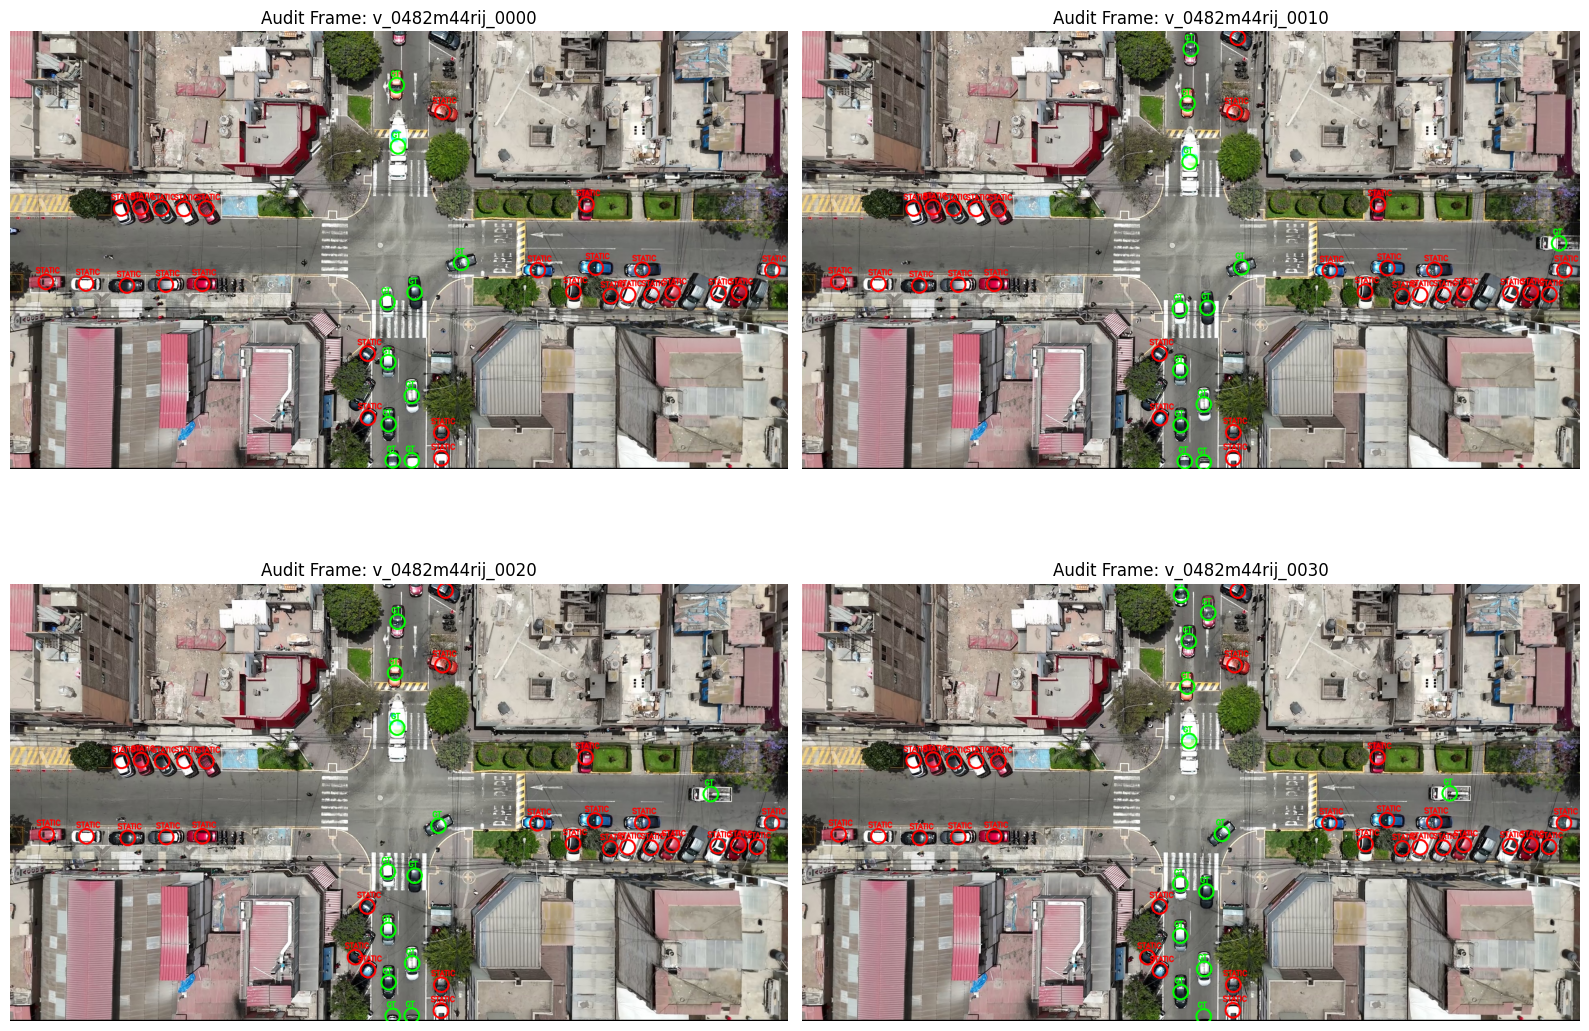

In [17]:
def visualize_audit_sequence(zip_path, clip_id, local_json_path, gt_df, start_frame=0, num_frames=4, step=10):
    """
    Plots a grid of sequence frames to perform a thorough manual audit.
    """
    print(f"=== Visual Audit Sequence: {clip_id} ===")

    # Load the generated JSON data
    with open(local_json_path, 'r') as f:
        static_data = json.load(f)

    clip_gt = gt_df[gt_df['clip_id'] == clip_id]

    with zipfile.ZipFile(zip_path, 'r') as z:
        zip_files = z.namelist()
        clip_frames = sorted([f for f in zip_files if clip_id in f and f.endswith(('.jpg', '.png'))])

        frames_to_show = []
        indices_to_show = range(start_frame, min(len(clip_frames), start_frame + num_frames * step), step)

        for idx in indices_to_show:
            frame_zip_path = clip_frames[idx]
            frame_id = os.path.basename(frame_zip_path).split('.')[0]

            with z.open(frame_zip_path) as file:
                img_bytes = file.read()
            nparr = np.frombuffer(img_bytes, np.uint8)
            img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 1. Draw Ground Truth moving vehicles in GREEN
            frame_gt = clip_gt[clip_gt['frame_idx'] == idx]
            for _, row in frame_gt.iterrows():
                cv2.circle(img_rgb, (int(row['cx']), int(row['cy'])), 18, (0, 255, 0), 3)
                cv2.putText(img_rgb, "GT", (int(row['cx']) - 15, int(row['cy']) - 22),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            # 2. Draw Detected Static Vehicles in RED
            frame_static = static_data.get(frame_id, [])
            for static_car in frame_static:
                cx, cy = int(static_car['cx']), int(static_car['cy'])
                cv2.circle(img_rgb, (cx, cy), 18, (255, 0, 0), 3)
                cv2.putText(img_rgb, "STATIC", (cx - 25, cy - 22),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

            frames_to_show.append((frame_id, img_rgb))

    # Draw in a grid (2 columns, rows as needed)
    cols = 2
    rows = math.ceil(len(frames_to_show) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
    axes = axes.flatten()

    for i, (frame_name, img_rgb) in enumerate(frames_to_show):
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Audit Frame: {frame_name}")
        axes[i].axis('off')

    # Turn off unused subplots
    for j in range(len(frames_to_show), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# --- CONFIGURACIÓN LOCAL DEL AUDIT ---
clip_to_audit = 'v_0482m44rij'
json_path_to_audit = '/content/tmp_pseudo/static_vehicles.json'
# -------------------------------------

# Get the pre-parsed GT DataFrame to run visualization
df_raw = pd.read_csv(CSV_PATH)
df_raw['clip_id'] = df_raw['Id'].apply(lambda x: '_'.join(x.split('_')[:-1]))

parsed_records = []
for _, row in df_raw[df_raw['clip_id'] == clip_to_audit].iterrows():
    frame_id = row['Id']
    target = row['Target']
    parts = frame_id.split('_')
    clip_id = '_'.join(parts[:-1])
    frame_idx = int(parts[-1])
    if target == 'none' or pd.isna(target):
        continue
    for ann in target.split(';'):
        parts_ann = ann.strip().split(' ')
        if len(parts_ann) == 6:
            parsed_records.append({
                'Id': frame_id, 'clip_id': clip_id, 'frame_idx': frame_idx,
                'cx': float(parts_ann[1]), 'cy': float(parts_ann[2])
            })
gt_sub_df = pd.DataFrame(parsed_records)

# Visualize sequence for the selected clip (Displays frames 0, 10, 20, 30 in a 2x2 grid)
visualize_audit_sequence(
    zip_path=IMAGES_ZIP_PATH,
    clip_id=clip_to_audit,
    local_json_path=json_path_to_audit,
    gt_df=gt_sub_df,
    start_frame=0,
    num_frames=4,
    step=10
)


In [18]:
# Ruta de tu cuaderno actual en Drive (ajústala si tiene otro nombre)
CUADERNO_PATH = "/content/drive/MyDrive/Colab Notebooks/pseudo_labeling.ipynb"
# Directorio de tu proyecto donde quieres guardar el Markdown y sus imágenes
DESTINO_DIR = "/content/drive/MyDrive/ia_article/temp"

# Ejecutamos la conversión redirigiendo la salida
!jupyter nbconvert --to markdown "$CUADERNO_PATH" --output-dir="$DESTINO_DIR"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/pseudo_labeling.ipynb to markdown
[NbConvertApp] Writing 24337 bytes to /content/drive/MyDrive/ia_article/temp/pseudo_labeling.md
